In [1]:
import numpy as np

In [3]:
# SVM model using numpy only
# generating random points
np.random.seed(0)
num_points = 100
X = np.random.randn(num_points, 2)
y = np.array([1 if x1**2 + x2**2 < 1 else -1 for x1, x2 in X])

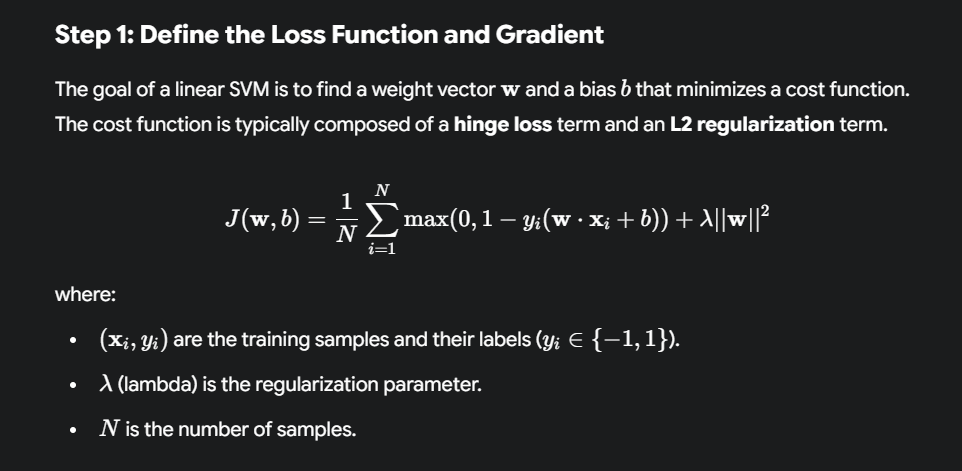

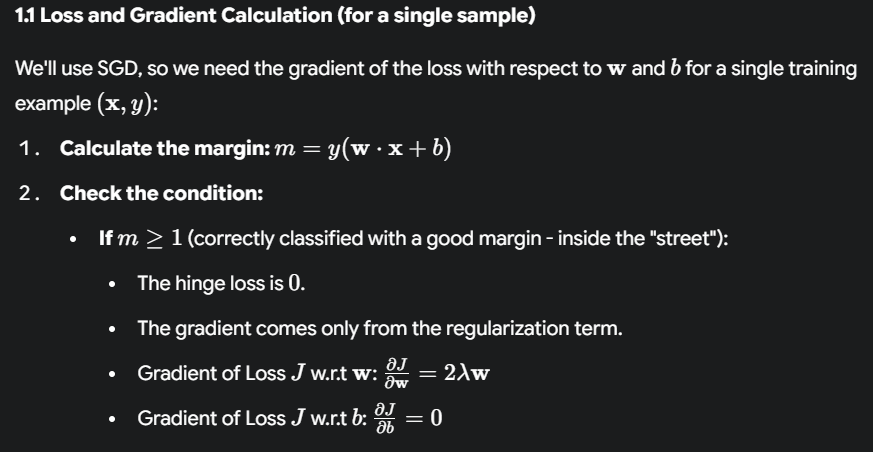

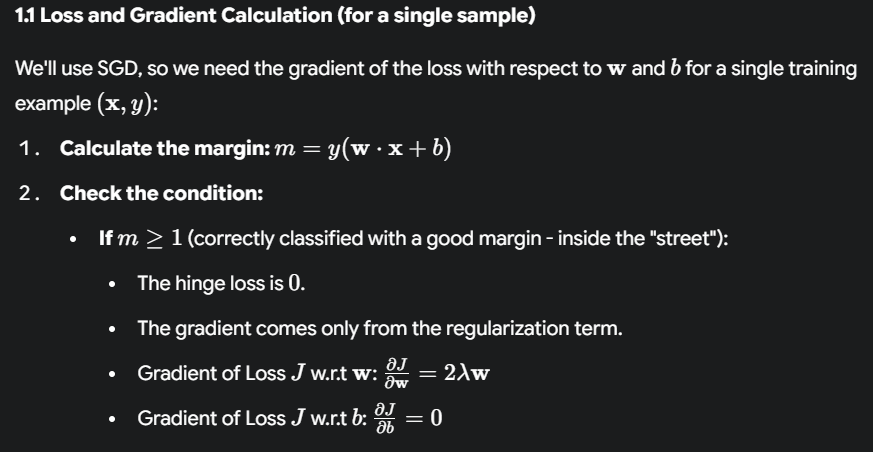

In [8]:
import numpy as np

class SVM_SGD:
    """A basic Linear SVM Classifier implemented using Stochastic Gradient Descent (SGD) with NumPy."""

    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate     # Learning rate (alpha)
        self.lambda_param = lambda_param  # Regularization parameter (lambda)
        self.n_iters = n_iters      # Number of iterations (epochs)
        self.w = None               # Weights vector
        self.b = None               # Bias scalar

    def _initialize_params(self, X):
        """Initialize weights and bias."""
        n_features = X.shape[1]
        # Initialize w to small random values and b to 0
        self.w = np.random.randn(n_features) * 0.01
        self.b = 0

    def fit(self, X, y):
        """Train the SVM model using SGD."""
        # Ensure labels are -1 or 1 (crucial for hinge loss)
        y_ = np.where(y <= 0, -1, 1)
        n_samples, n_features = X.shape

        self._initialize_params(X)

        # Stochastic Gradient Descent Loop
        for _ in range(self.n_iters):
            # Iterate over each sample
            for idx, x_i in enumerate(X):
                y_i = y_[idx]

                # 1. Calculate the prediction/score
                linear_model = np.dot(x_i, self.w) + self.b

                # 2. Check the condition (margin = y_i * linear_model)
                condition = y_i * linear_model >= 1

                # 3. Calculate Gradients and Update
                if condition:
                    # Gradient comes only from regularization (w * 2 * lambda)
                    dw = 2 * self.lambda_param * self.w
                    db = 0
                else:
                    # Gradient from regularization (w * 2 * lambda) MINUS (y_i * x_i)
                    dw = 2 * self.lambda_param * self.w - (y_i * x_i)
                    db = -y_i

                # Update the parameters (Gradient Descent step)
                self.w -= self.lr * dw
                self.b -= self.lr * db

    def predict(self, X):
        """Predict class labels for given samples."""
        linear_model = np.dot(X, self.w) + self.b
        # Return -1 or 1 based on the sign
        return np.sign(linear_model)

In [10]:
# Create Dummy Data
np.random.seed(42)
X = np.random.randn(50, 2)
# Create a linear boundary (e.g., x1 + x2 = 0)
y = np.where(X[:, 0] + X[:, 1] > 0, 1, -1) # Labels: 1 or -1

# Add some noise to make it realistic
X[y == -1] -= 1
X[y == 1] += 1

# Initialize and Train the SVM
svm = SVM_SGD(learning_rate=0.0001, lambda_param=0.01, n_iters=1000)
print("Starting training...")
svm.fit(X, y)
print("Training finished.")

# Make Predictions
predictions = svm.predict(X)

# Calculate Accuracy
accuracy = np.sum(predictions == y) / len(y)
print(f"Model Accuracy on Training Data: {accuracy * 100:.2f}%")
print(f"Learned Weights (w): {svm.w}")
print(f"Learned Bias (b): {svm.b}")

Starting training...
Training finished.
Model Accuracy on Training Data: 100.00%
Learned Weights (w): [0.46422272 0.51431938]
Learned Bias (b): -0.03970000000000011


In [ ]:
'''
Starting training...
Training finished.
Model Accuracy on Training Data: 100.00%
Learned Weights (w): [0.46422272 0.51431938]
Learned Bias (b): -0.03970000000000011
-------------------------------------------------

'''